# Test Unlabeled Spectrograms

This notebook tests a trained model on unlabeled spectrograms from .mat files.


In [ ]:
# Check which Python environment we're using
import sys
from pathlib import Path
import subprocess


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / '.git').exists():
            return parent
    try:
        root = subprocess.check_output(['git', 'rev-parse', '--show-toplevel'], text=True).strip()
        return Path(root)
    except Exception:
        return start


REPO_DIR = find_repo_root()

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Check if we're in the right venv
print(f"Virtual env: {sys.prefix}")
expected_venv = str(REPO_DIR / '.venv')
if expected_venv in sys.executable:
    print("✓ Using correct virtual environment")
else:
    print(f"✗ Wrong environment! Expected: {expected_venv}")
    print("Please restart kernel and ensure you're using the .venv environment")

import numpy as np
import torch
import scipy.io as sio
import h5py
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import yaml
import pandas as pd
import pickle

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Check if mamba-ssm is available
try:
    import mamba_ssm
    print(f"✓ mamba-ssm found: {mamba_ssm.__version__}")
except ImportError as e:
    print(f"✗ mamba-ssm not found: {e}")
    print("Kernel is using wrong environment - please restart!")

# add src to path so we can import our modules
sys.path.append('../src')
sys.path.append('../')

# test VisionMamba import
try:
    from src.ssamba.models.models_mamba import VisionMamba
    print("✓ VisionMamba imported successfully")
except Exception as e:
    print(f"✗ VisionMamba import failed: {e}")

from src.ssamba.dataset import ONCSpectrogramDataset
from src.ssamba.utilities.checkpoint_utils import load_checkpoint
from src.ssamba.utilities.training_utils import create_model
from src.ssamba.models.both_models import ASTModel, AMBAModel


Python executable: /home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/bin/python
Python version: 3.10.12 (main, Jan 17 2025, 14:35:34) [GCC 11.4.0]
Virtual env: /home/sbialek/ONC/selfsupervision_anomalies_onc/.venv
✓ Using correct virtual environment
PyTorch version: 2.7.1+cu126
CUDA available: True
✓ mamba-ssm found: 2.2.5
VisionMamba imported successfully
RMSNorm imported successfully
✓ VisionMamba imported successfully


/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [2]:
from src.ssamba.utilities.training_utils import create_model
from src.ssamba.models import AMBAModel

## Config and Setup


In [ ]:
# paths - change these to your actual paths
MAT_FILES_DIR = "/mnt/z/CIOOS_Anomaly_detection_work/EndeavourKEMFHH1/testset/ICLISTENHF6324/sampling_2024-11-20_to_2025-06-24/mat/processed/"  # folder containing .mat files
MODEL_PATH = str(REPO_DIR / "data/trained-model/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones-noexclude/models/ft-cls_best_checkpoint.pth")  # trained model checkpoint
OUTPUT_DIR = "test_results"                # where to save results

# model type - 'amba' for AMBA models, 'ast' for AST models
MODEL_TYPE = 'amba'  

# processing params (from config)
TARGET_SIZE = (512, 512)  # target spectrogram size
EXPECTED_SHAPE = (854, 1000)  # expected raw .mat shape
FILE_BATCH_SIZE = 16
INFERENCE_BATCH_SIZE = 16

DATASET_MEAN = 51.506817  # Set to "none" to calculate from dataset
DATASET_STD = 13.638703   # Set to "none" to calculate from dataset

# model params 
TARGET_LENGTH = 1024
NUM_MEL_BINS = 128
BATCH_SIZE = 16

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")
print(f"configured for {MODEL_TYPE} model")


using device: cuda
configured for amba model


In [ ]:
# Path to your model directory
#model_dir = Path("/scratch/merileo/exp/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-exp1")
model_dir = REPO_DIR / "data/trained-model/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones-noexclude"
checkpoint_path = str(model_dir / "models/ft-cls_best_checkpoint.pth")

# Load the saved args
with open(model_dir / "args.pkl", "rb") as f:
    args = pickle.load(f)

args.exp_dir = model_dir

# Create and load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model(args)
model = model.to(device)

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)

Vision Mamba Config: {'img_size': (512, 512), 'patch_size': 16, 'stride': 16, 'embed_dim': 768, 'depth': 24, 'channels': 1, 'num_classes': 2, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'norm_epsilon': 1e-05, 'rms_norm': False, 'residual_in_fp32': False, 'fused_add_norm': False, 'if_rope': False, 'if_rope_residual': False, 'bimamba_type': 'v2', 'if_cls_token': True, 'if_devide_out': True, 'use_double_cls_token': False, 'use_middle_cls_token': False, 'if_bidirectional': True, 'final_pool_type': 'none', 'if_abs_pos_embed': True, 'if_bimamba': False}
Loading pretrained model from: /scratch/merileo/exp/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
Loaded state dict keys: dict_keys(['epoch', 'global_step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metrics', 'val_acc', 'args'])
Now loading SSL pretrained model from /scratch/merileo/exp/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-cus

<All keys matched successfully>

## Data Processing Functions


In [9]:
def process_mat_file(mat_file_path, target_dim=TARGET_SIZE):
    """process a single .mat file like the training pipeline does"""
    try:
        mat_data = sio.loadmat(mat_file_path)
    except Exception as e:
        print(f"error loading {mat_file_path}: {e}")
        return None
    
    if 'SpectData' not in mat_data:
        print(f"no SpectData in {mat_file_path}")
        return None
    
    # extract spectrogram data (same as create_h5_dataset.py)
    data = mat_data['SpectData']['PSD'][0, 0]
    
    # handle padding if shortened
    if data.shape[1] < EXPECTED_SHAPE[1]:
        padding_width = ((0, 0), (0, EXPECTED_SHAPE[1] - data.shape[1]))
        data = np.pad(data, padding_width, mode='constant', constant_values=0)
    
    # handle -inf and nan values
    valid_mask = (data != -np.inf)
    data[~valid_mask] = 0
    data = np.nan_to_num(data, nan=0.0)
    
    # resize to target dimensions
    if target_dim:
        data = cv2.resize(data.squeeze(), target_dim)[..., np.newaxis]
    else:
        data = data[..., np.newaxis]
    
    return data

def normalize_data(data, dataset_mean=None, dataset_std=None, amount=1.0):
    """normalize data same way as training (from dataset.py)"""
    data = data.astype(np.float32)
    
    if dataset_mean is not None and dataset_std is not None:
        # use provided dataset statistics
        data = (data - dataset_mean) / (dataset_std * 2)
    else:
        # use percentile clipping and log transformation
        _min, _max = np.percentile(data, [amount, 100-amount])
        data = np.clip(data, _min, _max)
        data = np.log(data)
        data = (data - np.min(data)) / (np.max(data) - np.min(data))
    
    return np.nan_to_num(data, 0)


In [12]:
def get_mat_files_list(mat_dir):
    """get list of all .mat files without loading them"""
    mat_files = list(Path(mat_dir).glob("*.mat"))
    print(f"found {len(mat_files)} .mat files")
    return mat_files

def process_file_batch(mat_files_batch):
    """process a batch of .mat files"""
    spectrograms = []
    filenames = []
    
    for mat_file in mat_files_batch:
        data = process_mat_file(mat_file)
        if data is not None:
            spectrograms.append(data)
            filenames.append(mat_file.name)
    
    return np.array(spectrograms) if spectrograms else None, filenames

# get list of all mat files (without loading them)
all_mat_files = get_mat_files_list(MAT_FILES_DIR)
print(f"will process in batches of {FILE_BATCH_SIZE}")


found 1900 .mat files
will process in batches of 16


In [13]:
def run_inference_on_batch(model, spectrograms, batch_size=INFERENCE_BATCH_SIZE, device=device):
    """run model inference on a batch of spectrograms"""
    predictions = []
    probabilities = []
    
    # normalize and prepare data
    normalized_spectrograms = []
    for spec in spectrograms:
        normalized = normalize_data(spec, dataset_mean=DATASET_MEAN, dataset_std=DATASET_STD)
        normalized_spectrograms.append(normalized)
    
    normalized_spectrograms = np.array(normalized_spectrograms)
    
    # run inference in mini-batches
    with torch.no_grad():
        for i in range(0, len(normalized_spectrograms), batch_size):
            batch = normalized_spectrograms[i:i+batch_size]
            batch_permuted = []
            for j in range(len(batch)):
                batch_permuted.append(torch.from_numpy(batch[j]).permute(2, 0, 1))
            # convert to tensor and move to device
            batch_tensor = torch.stack(batch_permuted).float().to(device)
            
            # run model
            outputs = model(batch_tensor, task='ft_cls')
            
            # get probabilities and predictions
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            
            probabilities.extend(probs)
            predictions.extend(preds)

    print(f"predictions: {predictions}")
    print(f"probabilities: {probabilities}")
    
    return np.array(predictions), np.array(probabilities)

def process_all_files_in_batches(model, mat_files, file_batch_size=FILE_BATCH_SIZE):
    """process all files in batches to avoid memory issues"""
    print(f"processing {len(mat_files)} files in batches of {file_batch_size}")
    
    all_predictions = []
    all_probabilities = []
    all_filenames = []
    
    # process files in batches
    for i in tqdm(range(0, len(mat_files), file_batch_size), desc="processing file batches"):
        batch_files = mat_files[i:i+file_batch_size]
        
        # load and process this batch of files
        spectrograms, filenames = process_file_batch(batch_files)
        
        if spectrograms is not None and len(spectrograms) > 0:
            # run inference on this batch
            predictions, probabilities = run_inference_on_batch(model, spectrograms)
            
            # accumulate results
            all_predictions.extend(predictions)
            all_probabilities.extend(probabilities)
            all_filenames.extend(filenames)
            
            print(f"  processed batch {i//file_batch_size + 1}: {len(filenames)} files")
        
        # clear memory
        del spectrograms
        if 'predictions' in locals():
            del predictions, probabilities
    
    return np.array(all_predictions), np.array(all_probabilities), all_filenames

# run inference on all files in batches
predictions, probabilities, filenames = process_all_files_in_batches(model, all_mat_files)
print(f"inference complete - got {len(predictions)} predictions")


processing 1900 files in batches of 16


processing file batches:   1%|          | 1/119 [00:57<1:52:37, 57.27s/it]

predictions: [array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0])]
probabilities: [array([0.00249021], dtype=float32), array([0.00040797], dtype=float32), array([0.00021196], dtype=float32), array([0.00027522], dtype=float32), array([0.00066903], dtype=float32), array([0.00028092], dtype=float32), array([0.00043414], dtype=float32), array([0.00040191], dtype=float32), array([0.00027154], dtype=float32), array([0.00031798], dtype=float32), array([0.00043491], dtype=float32), array([0.00030371], dtype=float32), array([0.00151817], dtype=float32), array([0.00073823], dtype=float32), array([0.0004259], dtype=float32), array([0.00040197], dtype=float32)]
  processed batch 1: 16 files


processing file batches:   2%|▏         | 2/119 [01:54<1:51:29, 57.17s/it]

predictions: [array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0])]
probabilities: [array([0.00035555], dtype=float32), array([0.02841419], dtype=float32), array([0.00045969], dtype=float32), array([0.00577063], dtype=float32), array([0.00154021], dtype=float32), array([0.00085393], dtype=float32), array([0.00190824], dtype=float32), array([0.00062104], dtype=float32), array([0.00062216], dtype=float32), array([0.00240308], dtype=float32), array([0.00044795], dtype=float32), array([0.00075328], dtype=float32), array([0.00022662], dtype=float32), array([0.0005361], dtype=float32), array([0.00093292], dtype=float32), array([0.00041177], dtype=float32)]
  processed batch 2: 16 files


...

predictions: [array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0])]
probabilities: [array([0.00027841], dtype=float32), array([0.00028528], dtype=float32), array([0.00133581], dtype=float32), array([0.00196135], dtype=float32), array([0.00119594], dtype=float32), array([0.00094856], dtype=float32), array([0.00078023], dtype=float32), array([0.00100608], dtype=float32), array([0.00129598], dtype=float32), array([0.00062141], dtype=float32), array([0.00183792], dtype=float32), array([0.00270635], dtype=float32), array([0.00019826], dtype=float32), array([0.0010406], dtype=float32), array([0.00122564], dtype=float32), array([0.000865], dtype=float32)]
  processed batch 117: 16 files


processing file batches:  99%|█████████▉| 118/119 [1:39:12<00:53, 53.57s/it]

predictions: [array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0])]
probabilities: [array([0.00019681], dtype=float32), array([0.00031838], dtype=float32), array([0.00137812], dtype=float32), array([0.00039473], dtype=float32), array([0.00123454], dtype=float32), array([0.00029867], dtype=float32), array([0.00016055], dtype=float32), array([0.00052735], dtype=float32), array([0.00341156], dtype=float32), array([0.00066137], dtype=float32), array([0.0009869], dtype=float32), array([0.001866], dtype=float32), array([0.00045073], dtype=float32), array([0.00439261], dtype=float32), array([0.00085382], dtype=float32), array([0.00118584], dtype=float32)]
  processed batch 118: 16 files


processing file batches: 100%|██████████| 119/119 [1:39:51<00:00, 50.35s/it]

predictions: [array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0]), array([0])]
probabilities: [array([0.00200304], dtype=float32), array([0.00121965], dtype=float32), array([0.00068589], dtype=float32), array([0.00080592], dtype=float32), array([0.00832423], dtype=float32), array([0.00274741], dtype=float32), array([0.00343242], dtype=float32), array([0.0006289], dtype=float32), array([0.00100108], dtype=float32), array([0.00105537], dtype=float32), array([0.00037589], dtype=float32), array([0.00072295], dtype=float32)]
  processed batch 119: 12 files
inference complete - got 1900 predictions


## Results Analysis


prediction summary:
total files: 1900
predicted anomalies: 58
predicted normal: 1842
anomaly rate: 3.05%


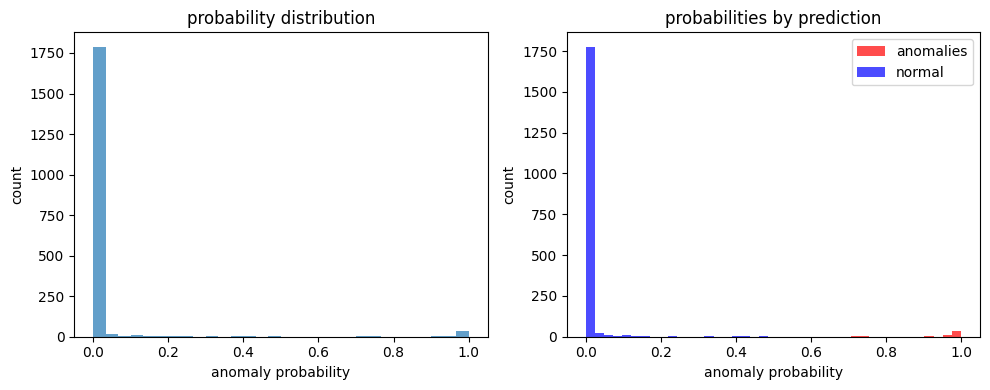

,filename,prediction,probability,is_anomaly
0,ICLISTENHF6324_20241120T003000.000Z_20241120T0...,0,0.002490,False
1,ICLISTENHF6324_20241120T003500.000Z_20241120T0...,0,0.000408,False
2,ICLISTENHF6324_20241120T004000.000Z_20241120T0...,0,0.000212,False
3,ICLISTENHF6324_20241120T004500.000Z_20241120T0...,0,0.000275,False
4,ICLISTENHF6324_20241120T005000.000Z_20241120T0...,0,0.000669,False


In [14]:
# create results dataframe
results_df = pd.DataFrame({
    'filename': filenames,
    'prediction': predictions.squeeze(),
    'probability': probabilities.squeeze(),
    'is_anomaly': predictions.squeeze() == 1
})

# basic stats
print("prediction summary:")
print(f"total files: {len(results_df)}")
print(f"predicted anomalies: {sum(results_df['is_anomaly'])}")
print(f"predicted normal: {sum(~results_df['is_anomaly'])}")
print(f"anomaly rate: {sum(results_df['is_anomaly'])/len(results_df):.2%}")

# show probability distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(probabilities, bins=30, alpha=0.7)
plt.title('probability distribution')
plt.xlabel('anomaly probability')
plt.ylabel('count')

plt.subplot(1, 2, 2)
plt.hist(probabilities[predictions.squeeze() == 1], bins=20, alpha=0.7, label='anomalies', color='red')
plt.hist(probabilities[predictions.squeeze() == 0], bins=20, alpha=0.7, label='normal', color='blue')
plt.title('probabilities by prediction')
plt.xlabel('anomaly probability')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

results_df.head()


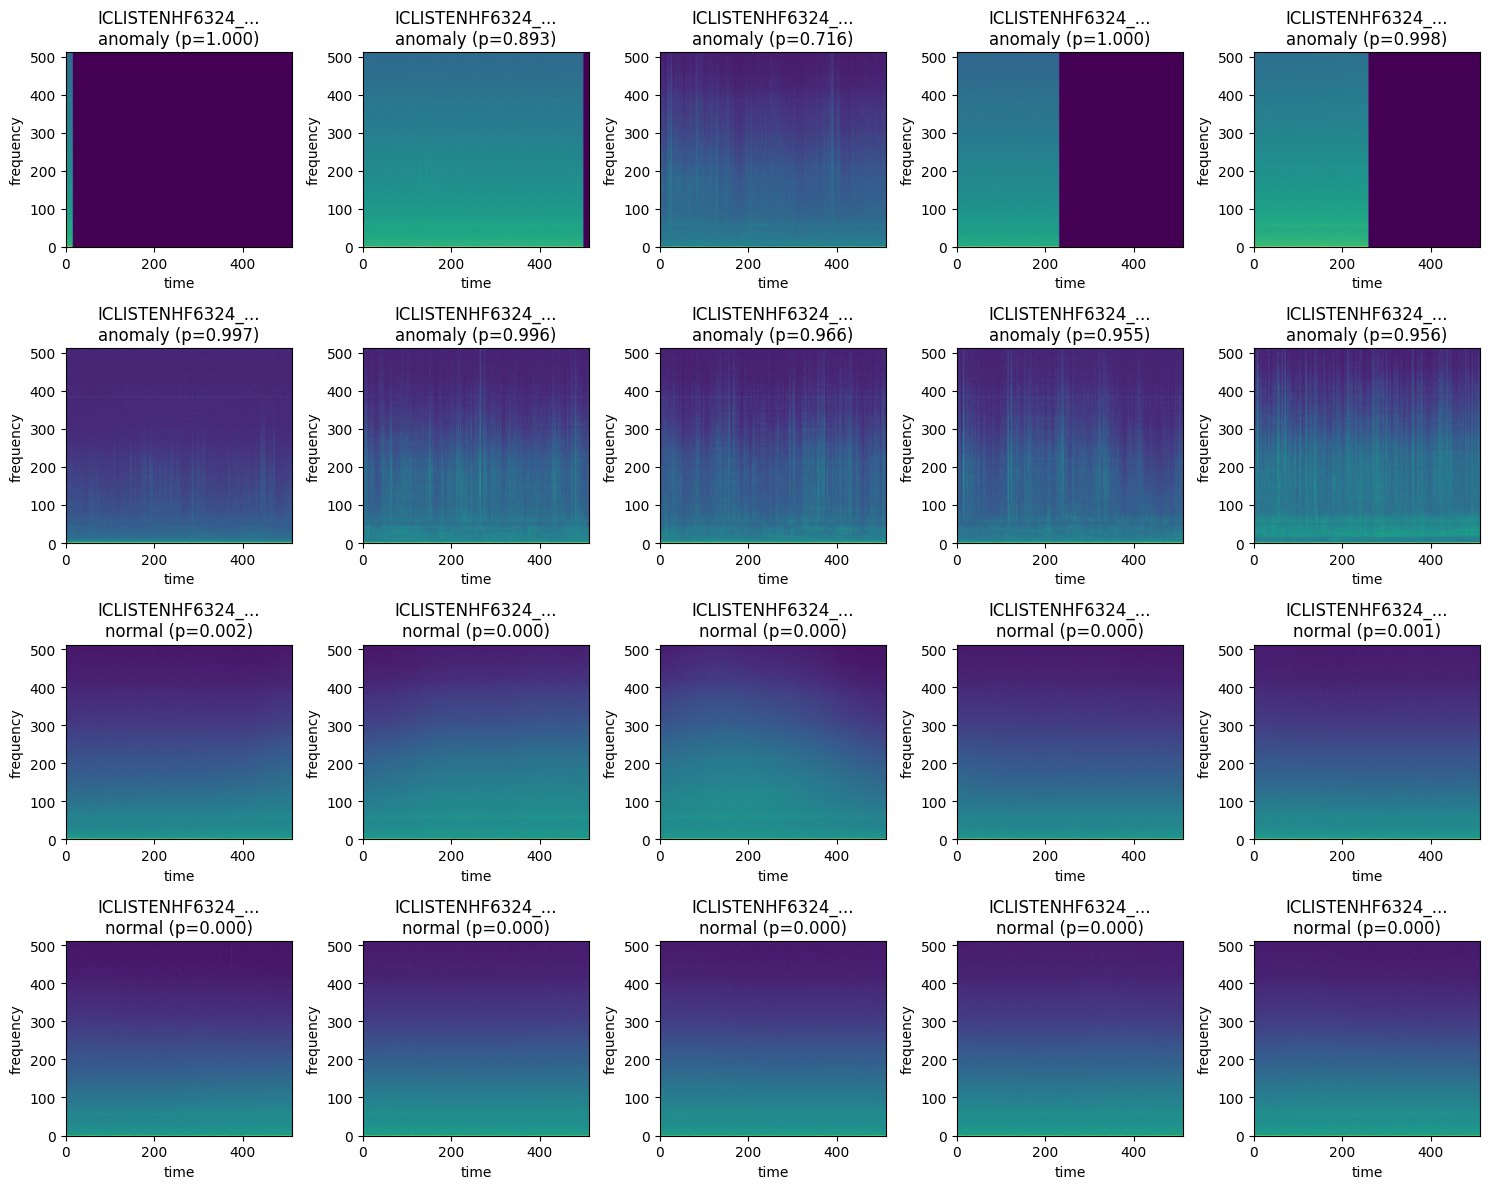

In [16]:
def plot_example_spectrograms(results_df, mat_files_dir, num_examples=4, plots_per_row=5):
    """plot example spectrograms with their predictions (loads files on-demand)"""
    
    # get some anomalies and some normal
    if sum(results_df['is_anomaly']) > 0:
        anomaly_indices = results_df[results_df['is_anomaly']].index[:num_examples//2]
    else:
        anomaly_indices = []
    
    if sum(~results_df['is_anomaly']) > 0:
        normal_indices = results_df[~results_df['is_anomaly']].index[:num_examples//2]
    else:
        normal_indices = []
    
    indices = list(anomaly_indices) + list(normal_indices)
    if not indices:
        print("no examples to plot")
        return
    
    # calculate rows needed for fixed number of columns
    num_rows = (len(indices) + plots_per_row - 1) // plots_per_row  # ceiling division
    
    fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(plots_per_row * 3, num_rows * 3))
    
    # handle single row case
    if num_rows == 1:
        if plots_per_row == 1:
            axes = [axes]
        else:
            axes = axes.reshape(1, -1)
    
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        # load the specific file
        filename = results_df.iloc[idx]['filename']
        mat_file_path = Path(mat_files_dir) / filename
        
        spec_data = process_mat_file(mat_file_path)
        if spec_data is not None:
            normalized = normalize_data(spec_data, dataset_mean=DATASET_MEAN, dataset_std=DATASET_STD).squeeze()
            
            axes[i].imshow(normalized, aspect='auto', origin='lower', cmap='viridis')
            
            prob = results_df.iloc[idx]['probability']
            pred = "anomaly" if results_df.iloc[idx]['is_anomaly'] else "normal"
            
            axes[i].set_title(f"{filename[:15]}...\n{pred} (p={prob:.3f})")
            axes[i].set_xlabel('time')
            axes[i].set_ylabel('frequency')
    
    # hide unused subplots
    for i in range(len(indices), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# plot some examples (loads files on-demand to save memory)
plot_example_spectrograms(results_df, MAT_FILES_DIR, num_examples=20)


In [65]:
def plot_spectrograms(spectrograms):
    """Plot spectrograms"""
    for spec in spectrograms:
        plt.imshow(spec, aspect='auto', origin='lower', cmap='viridis')
        plt.show()

def plot_normal_spectrograms(results_df, mat_files_dir):
    """Plot normal spectrograms from the results dataframe"""
    # Get the normal indices
    normal_indices = results_df[~results_df['is_anomaly']].index
    
    # Get the spectrograms
    spectrograms = []
    for idx in normal_indices:
        filename = results_df.iloc[idx]['filename']
        mat_file_path = Path(mat_files_dir) / filename
        spec_data = process_mat_file(mat_file_path)
        spectrograms.append(spec_data)

    # Plot the spectrograms
    plot_spectrograms(spectrograms)

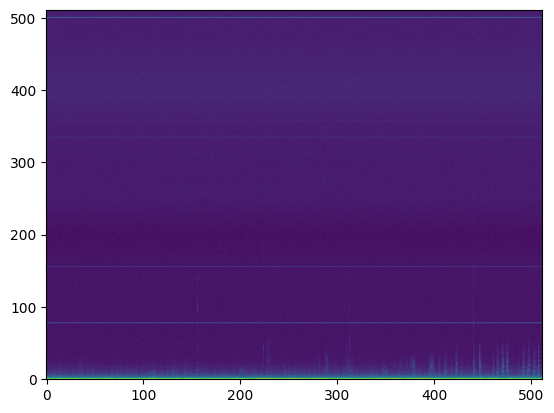

In [67]:
plot_normal_spectrograms(results_df, MAT_FILES_DIR)

In [64]:
# save results
Path(OUTPUT_DIR).mkdir(exist_ok=True)
results_df.to_csv(f"{OUTPUT_DIR}/test_results.csv", index=False)
print(f"results saved to {OUTPUT_DIR}/test_results.csv")

# save high-confidence anomalies for manual review
high_conf_anomalies = results_df[
    (results_df['is_anomaly']) & 
    (results_df['probability'] > 0.8)
].sort_values('probability', ascending=False)

if len(high_conf_anomalies) > 0:
    high_conf_anomalies.to_csv(f"{OUTPUT_DIR}/high_confidence_anomalies.csv", index=False)
    print(f"found {len(high_conf_anomalies)} high-confidence anomalies")
    print("top 5:")
    print(high_conf_anomalies[['filename', 'probability']].head())
else:
    print("no high-confidence anomalies found")

print("\ntesting complete! check the output directory for results.")


results saved to test_results/test_results.csv
found 778 high-confidence anomalies
top 5:
                                              filename  probability
520  ICLISTENHF6095_20250301T154500.000Z_20250301T1...     0.999928
755  ICLISTENHF6095_20250505T153500.000Z_20250505T1...     0.999907
521  ICLISTENHF6095_20250301T154848.500Z_20250301T1...     0.999896
731  ICLISTENHF6095_20250429T040000.000Z_20250429T0...     0.999880
730  ICLISTENHF6095_20250429T035500.000Z_20250429T0...     0.999872

testing complete! check the output directory for results.
